#### Business Understanding
#### Project Title

##### Blood Donation Prediction

#### Problem Statement

Blood donation is essential for saving lives. Blood banks need to maintain an adequate supply of blood for emergencies, surgeries, and treatments.

The objective of this project is to predict whether a donor will donate blood again in March 2007 based on their donation history.

#### Business Objective

The Blood Transfusion Service Center wants to identify donors who are likely to donate blood again.

This helps:

- Improve blood collection campaigns
- Target potential donors
- Reduce marketing costs
- Maintain sufficient blood supply

#### Machine Learning Objective

Build a classification model that predicts:

Target Variable

Made Donation in March 2007

Value	Meaning
0	Did Not Donate
1	Donated


#### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#### Load Dataset


In [2]:
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")

#### View Dataset

In [3]:
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [4]:
df.tail()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0
575,74,72,1,250,72,0


The dataset contains donor information such as donation frequency, recency, total volume donated, and donation history.

The target variable indicates whether the donor donated blood in March 2007.

#### Data Shape

In [5]:
df.shape

(576, 6)

- The dataset contains multiple donor records and several attributes related to donation history.

#### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


- All features are numerical.

- No datatype conversion is required.

#### Statistical Summary

In [7]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


- The summary statistics provide information about donor behavior and donation frequency.

In [8]:
df.isnull().sum()

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

In [9]:
df.duplicated().sum()

0

#### Removing Unneccessary Columns

In [10]:
df.drop('Unnamed: 0',axis=1,inplace =True)

### Exploratory Data Analysis(EDA)
#### Understanding the Target Variable

In [11]:
df['Made Donation in March 2007'].value_counts()

Made Donation in March 2007
0    438
1    138
Name: count, dtype: int64

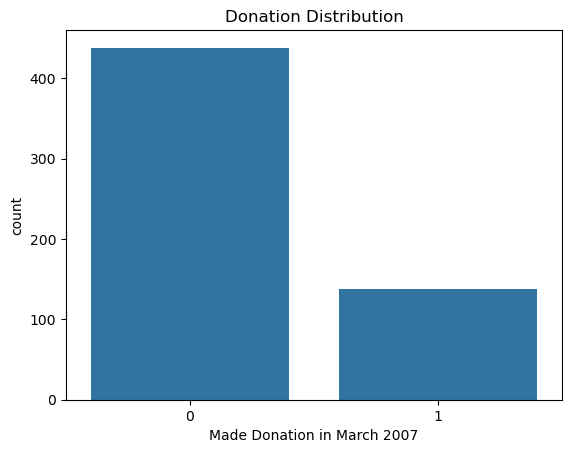

In [12]:
sns.countplot(x ='Made Donation in March 2007',data=df)
plt.title('Donation Distribution')
plt.show()

#### Observation
- Most donors did not donate again.
- Fewer donors donated in March 2007.

The blood bank faces a challenge because only a small percentage of previous donors returned.

In [13]:
df['Made Donation in March 2007'].value_counts(normalize=True)*100

Made Donation in March 2007
0    76.041667
1    23.958333
Name: proportion, dtype: float64

- Only about 1 out of every 4 donors returned to donate again.

#### Months Since Last Donation

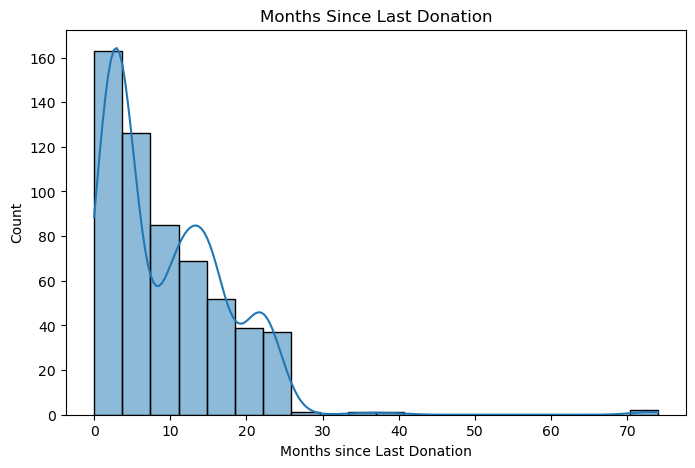

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Months since Last Donation'],bins=20,kde=True)
plt.title('Months Since Last Donation')
plt.show()

- Lower values indicate recent donors.

- Recent donors may have a higher probability of donating again.

#### Number of Donation

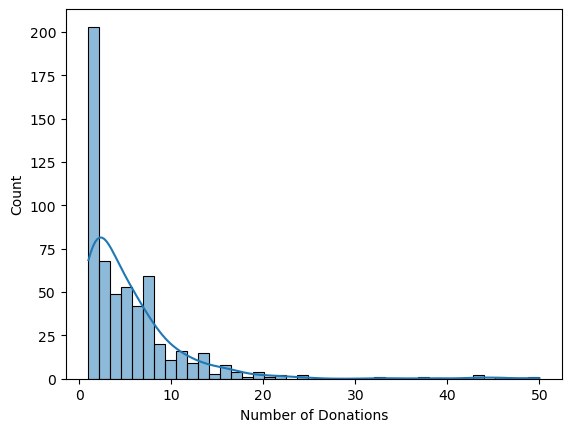

In [15]:
sns.histplot(df['Number of Donations'],kde=True)
plt.show()

- Frequent donors are generally more likely to donate again.

#### Correlation Heatmap

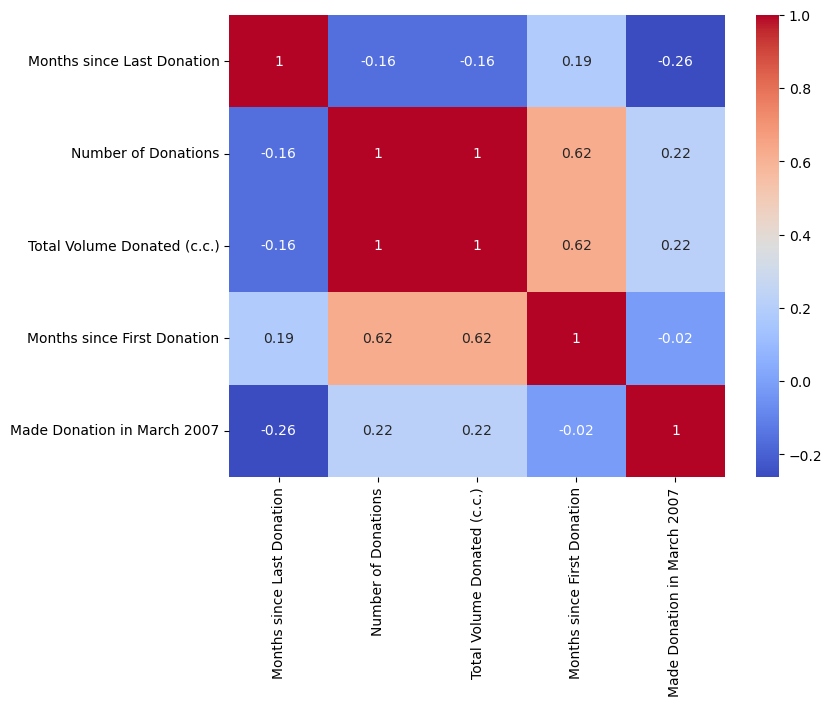

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

- The heatmap helps identify relationships among donor attributes and the target variable.

#### Feature Selection

In [17]:
X= df.drop('Made Donation in March 2007',axis=1)
y=df['Made Donation in March 2007']

In [18]:
print(X.shape)
print(y.shape)

(576, 4)
(576,)


The independent variables contain donor-related information.

The dependent variable indicates whether the donor donated blood in March 2007.

#### Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

80% of the data is used for training and 20% for testing.

This helps evaluate the model on unseen data.

#### Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

- Feature scaling standardizes all variables and improves model performance.

#### Model Building

#### 1. Logistic Regression

In [21]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(
    y_test,pred_lr)
print(acc_lr)

0.7586206896551724


#### 2. Decision Tree

In [22]:
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test,pred_dt)
print(acc_dt)

0.6810344827586207


#### 3. Random Forest

In [23]:
rf= RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test,pred_rf)
print(acc_rf)

0.7155172413793104


#### 4. KNN

In [24]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test,pred_knn)
print(acc_knn)

0.8017241379310345


#### 5. SVM

In [25]:
svm = SVC()
svm.fit(X_train_scaled,y_train)
pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test,pred_svm)
print(acc_svm)

0.7586206896551724


#### Model Comparison

In [26]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'Random Forest',
             'KNN',
             'SVM'
            ],
    'Accuracy':[
        acc_lr,
        acc_dt,
        acc_rf,
        acc_knn,
        acc_svm
    ]
})
results.sort_values(
    by= 'Accuracy',
    ascending=False
)

,Model,Accuracy
3,KNN,0.801724
0,Logistic Regression,0.758621
4,SVM,0.758621
2,Random Forest,0.715517
1,Decision Tree,0.681034


#### Visualization

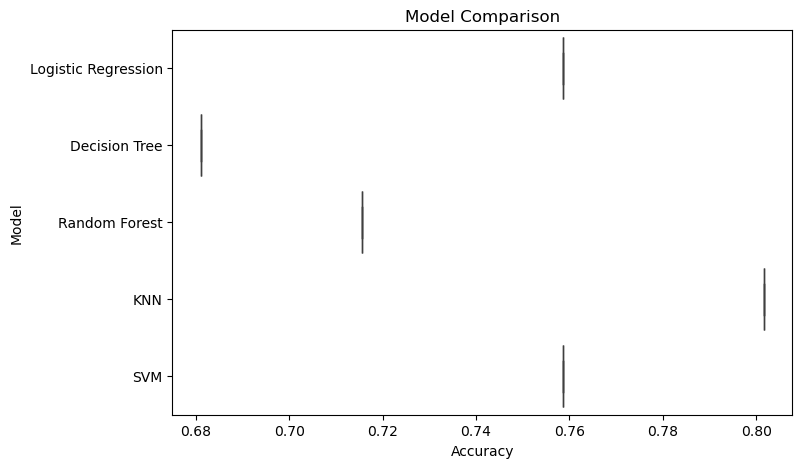

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Accuracy',y='Model',data=results)
plt.title('Model Comparison')
plt.show()

#### Best Model Evaluation

In [28]:
print(classification_report(y_test,pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87        87
           1       0.64      0.48      0.55        29

    accuracy                           0.80       116
   macro avg       0.74      0.70      0.71       116
weighted avg       0.79      0.80      0.79       116



#### Confusion Matrix

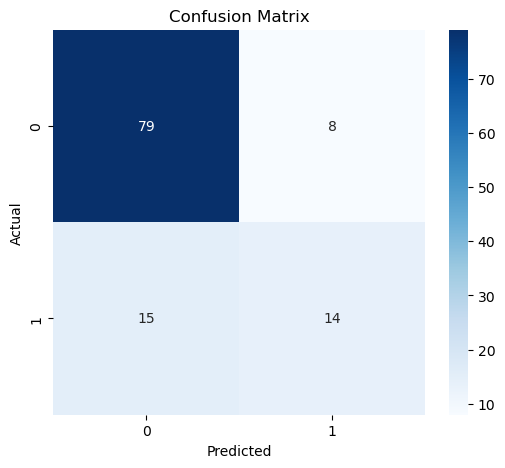

In [29]:
cm = confusion_matrix(
    y_test,pred_knn
)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,annot=True,fmt='d',cmap='Blues'
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Feature Importance

In [30]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance': rf.feature_importances_
})
importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
    )
importance

,Feature,Importance
3,Months since First Donation,0.418818
0,Months since Last Donation,0.268934
1,Number of Donations,0.160228
2,Total Volume Donated (c.c.),0.152020


#### Plot

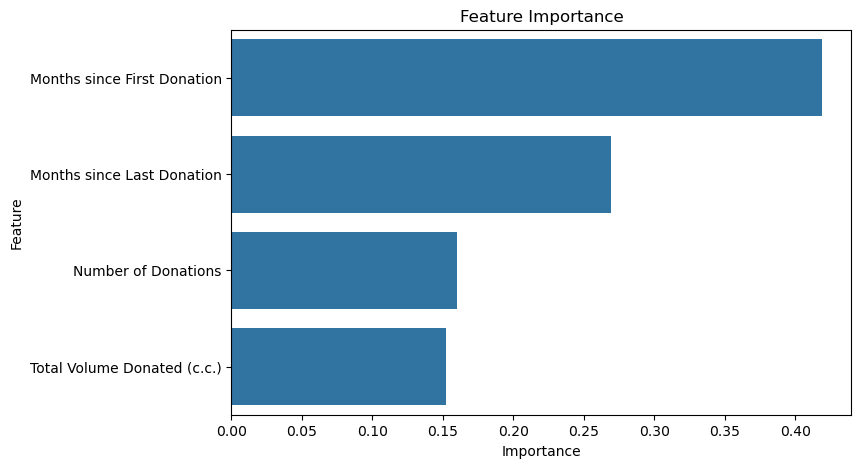

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=importance)
plt.title('Feature Importance')
plt.show()

 #### Model Comparison Report

Five machine learning models were developed and evaluated for predicting whether a donor would donate blood in March 2007.

The performance of each model was measured using accuracy score.

Results:

1. KNN achieved the highest accuracy of 80.17%.
2. Logistic Regression achieved 75.86%.
3. SVM achieved 75.86%.
4. Random Forest achieved 71.55%.
5. Decision Tree achieved 68.10%.

Based on the evaluation results, KNN outperformed all other models and was selected as the final model for prediction.

#### Observation on KNN
KNN performed best because donors with similar donation histories tend to exhibit similar future donation behavior.

The algorithm effectively identified patterns among donors based on recency, frequency, and total donation volume.

#### Expected Business Insight

1. Months since Last Donation
   - Donors who donated recently are more likely to donate again.
2. Number of Donations
   - Regular donors have a higher probability of future donations.
3. Total Volume Donated
   - Donors with higher cumulative donations are generally more committed and likely to continue donating.
4. Months since First Donation
   - Long-term donors often show stronger engagement with blood donation programs.

#### Business Impact Report



1. Understanding donor behavior patterns.

2. Identifying factors influencing repeat donations.

3. Selecting the most effective classification model.

4. Handling possible class imbalance.

5. Translating model results into business recommendations.

#### Challenges faced

1. Understanding donor behavior patterns.

2. Identifying factors influencing repeat donations.

3. Selecting the most effective classification model.

4. Handling possible class imbalance.

5. Translating model results into business recommendations.

#### Production Recommendation

Based on model evaluation results, KNN is recommended for deployment as it achieved the highest prediction accuracy of 80.17%.

The blood donation center can use this model to identify potential future donors and target them through personalized awareness campaigns.

This approach can improve blood collection efficiency and help maintain adequate blood supplies.

#### Final Conclusion

A predictive model was developed to identify donors likely to donate blood in March 2007.

EDA showed that donation frequency and donation recency play a major role in predicting future donations.

Multiple machine learning models were evaluated and the best-performing model was selected based on accuracy.

The developed model can help blood banks improve donor targeting, optimize campaigns, and maintain a stable blood supply.